**Content Produced by UF Signal Processing Society**

**Authors: Awwab Azam**

# Intro to Deep Learning using PyTorch

This is the first of a planned 3-part series covering the basics of deep learning for applications in Physics and Engineering. In this workshop, we will learn how to use PyTorch to train a very simple neural network, as well as some hand-wavy ML theory. Let's get started!

### Setup

For this tutorial, we will need several Python packages, including PyTorch, NumPy, and MatplotLib. If you are not very tech-savvy, the easiest thing to do would be to open this notebook in Google Colab using the link at the top. Google Colab is an online cloud-based development environment that comes with all these packages preinstalled.

For those who are comfortable working with Python virtual environments and would like to run the code locally, please make sure you have all the packages in the import section installed.

## 0. Getting started

First we need to import the packages that we want to use.

In [14]:
# imports
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from typing import Tuple

## 1. Tensors

The foundational building block in PyTorch is a tensor, which is basically a multidimensional array. You can make a tensor in several ways, as follows. Random tensors are often useful if you want dummy data to test your model.

In [2]:
# a tensor of zeroes
zero_tensor = torch.zeros(2, 2)
# a tensor of ones
ones_tensor = torch.ones(2, 2)
# a tensor of random numbers
randn_tensor = torch.randn(2, 2)

print(zero_tensor)
print(ones_tensor)
print(randn_tensor)

tensor([[0., 0.],
        [0., 0.]])
tensor([[1., 1.],
        [1., 1.]])
tensor([[ 1.3684, -1.2402],
        [-1.1525,  1.3187]])


You can also make a tensor from a NumPy array and vice versa. The PyTorch tensor and the NumPy array will share the same underlying memory, so be careful if you change anything!

In [3]:
np_arr = np.random.random((2, 2))
# should be random
print(np_arr)

tensor = torch.from_numpy(np_arr)
tensor[0, 0] = 0
# should have a zero in the top left corner
print(np_arr)

# notice that we never directly modified np_arr!

[[0.36182534 0.68329072]
 [0.37203033 0.91675127]]
[[0.         0.68329072]
 [0.37203033 0.91675127]]


### Indexing and slicing

If you're familiar with NumPy, PyTorch indexing/slicing is quite similar. If not, no problem, we'll go through it step-by-step.

First things first: Python is 0-indexed, which means that the first element of any dimension in a tensor (or array, or list, etc) IS 0, NOT 1. You can ask a specific element by using the syntax `T[i]` where T is an arbitrary 1D tensor and i is the (0-based) index. If you have more dimensions, you can simply use more indices, i.e. `T[x, y, z]` for a 3D tensor.

Also, keep in mind that (just like in linear algebra), Python is row-major, so e.g. for 2D arrays, the first index determines the **row** and the second index determined the **column**.

You can use a colon : to select all elements in a certain dimension, and an ellipsis ... to select all elements from an unspecified number of dimensions.

In [4]:
# make a random 3D tensor (5x4x4)
T = torch.randn(5, 4, 4)
print(T)

# get a specific element
print(T[0, 1, 3])

# get the 1st 4x4 matrix
f = T[0, :, :]
print(f)

# alternatively, you can use an ellipsis
print(T[0, ...] == f)

tensor([[[ 1.1509, -0.6649, -1.3165, -0.9094],
         [ 0.1087,  1.7038, -0.6667, -0.9270],
         [-0.0766, -0.6714,  0.3649,  0.2407],
         [ 0.2219, -1.7722,  0.1219,  1.0914]],

        [[-1.2462,  0.3461, -2.9911,  1.5522],
         [-1.6936, -1.7390, -1.3108,  0.3075],
         [-0.0845, -1.1424,  0.4381, -1.3992],
         [-0.1484, -0.2707, -0.5350,  1.1189]],

        [[-1.3290,  1.2973,  1.0515, -1.9729],
         [ 0.0297, -0.5194, -0.1966, -1.4176],
         [ 1.2531,  0.6463, -0.1845, -0.0680],
         [-2.7005, -1.8139, -0.5194,  0.7533]],

        [[ 0.7922, -0.5276, -2.9377,  1.0234],
         [ 0.0184,  0.2780, -1.1187, -1.0797],
         [-0.0071,  1.4487,  0.2860, -1.0793],
         [ 0.0890, -0.2658,  2.0013, -1.0025]],

        [[-1.3696,  0.8295, -0.9726,  0.0276],
         [ 0.4507, -0.8276,  0.1185,  1.2797],
         [-1.2181,  0.9351,  0.4994,  0.0509],
         [ 1.5566,  0.9930,  0.1263, -0.9361]]])
tensor(-0.9270)
tensor([[ 1.1509, -0.6649, -1.3165

These are the basics of how to make, index, and slice tensors. However, there are many, many more essential tensor operations (e.g. `reshape`, `expand`, `repeat`, etcetera) that you can use to make life easier for yourself. Going through each of these in detail is outside the scope of this introductory workshop, but the material covered above should be enough to get you started. Personally, I would suggest that whenever you have to do any kind of remotely complicated tensor manipulation, first search whether there's a built-in function to do it for you (many times there will be!). AI tools (like ChatGPT) and Google are excellent for this purpose. As you work more with PyTorch, eventually you'll get the hang of it and using these functions will become muscle memory.

### Vectorization

A fundamental concept in PyTorch is that we want to "vectorize" everything - that is, instead of using for loops or iterators, we want to transform our problem in terms of operations on a vector in order to make it easily parallelizable on GPUs. For example, let's say we wanted to apply the function $x \Rightarrow sin(x)$ to every element of a vector. Here's how you would do it "normally" (i.e., the way you were probably taught to write code):

In [5]:
# sequential code
x = torch.randn(10)  # a random 1D tensor for this example
y1 = torch.zeros_like(x)  # this makes a tensor of zeros of the same shape as x
for i in range(len(x)):
    y1[i] = torch.sin(x[i])

The above code certainly works! However, notice that it is sequential in nature, because it iterates over the elements of the tensor one-by-one. This is fine for a toy example like this one, but it becomes problematic when you want to do operations on large tensors to train ML models. Instead, it is much more efficient to run the operation over all elements of the tensor at the same time, which is better suited to take advantage of modern GPUs' inherent parallelism capabilities.

In [6]:
# parallel code
y2 = torch.sin(x)  # we can pass a whole tensor into the torch.sin function!

# check to see they're equal
print(torch.equal(y1, y2))

True


This is just one example. However, there are a plethora of other functions that can similarly act on whole tensors at the same time, such as `torch.log`, `torch.transpose`, and many more. To put it simply, the philosophy of PyTorch is "if it can be vectorized, it will be vectorized."

## 2. Datasets & Dataloaders

### Data Generation and Preprocessing

The basic premise of machine learning is to define a function as an ansatz with some number of free parameters, and then optimize those parameters based on the training data. Thus, data is a fundamental part of the process to train any neural network. In PyTorch, we can use the Dataset class as a flexible container for our data.

For this example (since this is supposed to be machine learning for physics applications, after all) we take the sample task of computing the 2D (discrete) Fourier transform of a 16x16 matrix. Thankfully, PyTorch already has a built-in Fast Fourier Transform (FFT) function, so we can generate our data easily. For simplicity, we start with 1000 input/output samples.

In [7]:
# make the input tensor - 1K samples of 16x16 matrices
input_matrices = torch.randn(1000, 16, 16)
output_matrices = torch.fft.fft2(input_matrices)

Let's check the data types of our inputs and outputs. In PyTorch, you can do this using the .dtype property. The data type is generally either an `int` (integer), `float` (decimal), `complex` (complex decimal), or `bool` (Boolean value i.e. True/False), followed by the number of bits used to represent the number (for numeric dtypes) in memory. More bits obviously mean a higher range/precision, but also more memory usage. The most common dtype you will use will probably be `float32` (i.e., a decimal number stored in 32 bits, or 4 bytes of memory).

In [8]:
print(f"Input Data Type: {input_matrices.dtype}")
print(f"Output Data Type: {output_matrices.dtype}")

Input Data Type: torch.float32
Output Data Type: torch.complex64


Oh wait! Our outputs are complex numbers! If you don't remember the formula for the FFT (I don't), here it is:

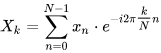

As you can see, there is a factor of $i$, the imaginary unit, so it makes sense that `output_matrices` has a complex data type. In physics applications, especially when doing anything related to quantum mechanics, it is common for complex numbers to show up everywhere, so we need to know how to handle them properly.

Although there are some third-party libraries designed specifically for complex-valued inputs/outputs, PyTorch itself has very limited support for complex numbers. However, we can get around this hurdle by realizing that a complex number can be viewed as a 2D vector with real components. This is the approach we will take in this tutorial.

First off, our eventual goal is to use a simple feedforward neural network to model the relationship between our inputs and outputs. Although there exist more advanced architectures like convolutional neural networks (CNNs) and neural operators that can handle multidimensional data, a vanilla NN has a single, 1D vector as its input and output.

For this reason, we have to first flatten our data before feeding it into the model. The (real) inputs will be flattened into a $16*16=256$-long vector, while the (complex) outputs will be flattened into a $16*16*2=512$-long vector, where the extra factor of 2 in the outputs is due to considering both the real and complex part.

In [9]:
# note that we cannot simply call the .flatten() function here, because we need to preserve the index/batch dimension
num_samples = input_matrices.shape[0]  # should be 1K
# a value of -1 in the reshape function means "infer the size of this dimension based on the others". In this case, the effect is to flatten each individual matrix into a 1D vector
input_matrices = input_matrices.reshape(num_samples, -1)
output_matrices = output_matrices.reshape(num_samples, -1)
output_matrices = torch.cat(
    (output_matrices.real, output_matrices.imag), dim=-1
)  # this extra step is required to concatenate the real and imaginary parts along the embedding dimension

# check shapes
print(f"Input Shape: {input_matrices.shape}")
print(f"Output Shape: {output_matrices.shape}")

Input Shape: torch.Size([1000, 256])
Output Shape: torch.Size([1000, 512])


At this stage, we have our data in the right form. Technically, we could go ahead and train our model on it directly. However, most of the time, the data you are dealing with will be generated by experiments or numerical simulations, and we don't want to have to make new data every time, so we should probably save it to disk. For (relatively) small datasets like this one, we can just store the whole tensor as a `.pt` file using PyTorch's built-in `torch.save()` function. However, for larger datasets, you will want to convert to a NumPy array and store it in a `.h5` file instead.

In [10]:
# save our data to disk so we don't have to regenerate it each time.
torch.save(input_matrices, "inputs.pt")
torch.save(output_matrices, "outputs.pt")

### Making a custom Dataset

OK great, so now we have our processed data saved to disk. How do we feed it into our neural network? For this purpose, PyTorch has the Dataset class. We can make our own custom Dataset as long as we implement three functions: `__init__` (the constructor), `__len__` to find the length of the datasets, and `__getitem__` to get a single (input, output) pair. As the double underscores surrounding their names indicates, these functions are not meant to be accessed directly by the user (although they can be), but rather so that PyTorch has the information it needs when we make a dataloader object (more on that later).

For our purposes, the Dataset will be relatively simple, but you can add more functionality if, for example, you want to load each sample from disk individually in case the whole dataset doesn't fit into memory, or if you want easier ways of dividing it into train/test splits (more on that later).

In [11]:
class FourierTransformDataset(Dataset):
    def __init__(
        self,
        input_filename: str,
        output_filename: str,
        indices: Tuple[int, int],
        transform=None,
        target_transform=None,
    ):
        # get start and end indices
        start_index = indices[0]
        end_index = indices[1]
        # load datasets and split them based on indices
        self.input_data = torch.load(input_filename, weights_only=True)[
            start_index:end_index
        ]
        self.output_data = torch.load(output_filename, weights_only=True)[
            start_index:end_index
        ]
        # get transformation functions
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(
            self.input_data
        )  # could do it with output_data too, would be equivalent

    def __getitem__(self, idx):
        # get input and output vectors
        input = self.input_data[idx]
        output = self.output_data[idx]
        # apply transformations (this will become very important later on!)
        if self.transform:
            input = self.transform(input)
        if self.target_transform:
            output = self.target_transform(output)
        return input, output

### Wrapping it with a Dataloader

OK great, so now we also have a custom Dataset class. Now what we need to do is to wrap it in a Dataloader. The Dataloader object is what will ultimately feed our data to the neural network during training. We can leave that part off until we build the model, but we can test out a toy Dataloader to see how it works.

In [12]:
sample_dataset = FourierTransformDataset(
    input_filename="inputs.pt",
    output_filename="outputs.pt",
    indices=(0, 10),  # this is just a toy example
)
toy_dataloader = DataLoader(sample_dataset, batch_size=5, shuffle=True)

As you can see, the dataloader takes in a Dataset as input. The `batch_size` determines the size of each batch during training. Basically, instead of updating the weights and biases only after running through the whole dataset, we split the dataset into little chunks and update the model parameters after collecting the gradients for each chunk. These "chunks" or batches need to be sampled randomly so that they are representative of the whole dataset, which is why we set `shuffle` to True.

I'm sorry if this sounds like a lot of jargon, but don't worry, we'll cover these things in more detail when we get to building the neural network. For now, though, let's see test out our `toy_dataloader`. It is basically an iterable of (input, output) pairs, so we can access individual elements with the `iter()` function.

In [13]:
inputs, outputs = next(iter(toy_dataloader))
print(f"Input batch shape: {inputs.shape}")
print(f"Output batch shape: {outputs.size()}")

Input batch shape: torch.Size([5, 256])
Output batch shape: torch.Size([5, 512])


Alright, great! Now that we have our data set up, we can get to building our neural network

## 3. Building the Neural Network

The model we build in this workshop will be a simple multilayer perceptron (MLP), consisting of alternating linear layers and nonlinearities. This is probably the most basic deep learning model possible, but according to the Universal Approximation Theorem, an MLP can approximate any function given enough training data and parameters, so hopefully, it should be able to model our Fourier Transform task.

Before we begin the actual code, it might be helpful to understand how an MLP actually works. Mathematically, the outputs of a single MLP layer, with input dimension $\mathbb{R}^n$ and output dimension $\mathbb{R}^m$ can be expressed as:

$$\sigma(Wx + B)$$

where $W \in \mathcal{M}_{\mathbb{R}^m \times \mathbb{R}^n}$ is the weight matrix containing learnable parameters (the weights), $B \in \mathbb{R}^m$ is the bias vector, and $\sigma$ is a nonlinear activation function.

Both $W$ and $B$ are filled with learnable parameters - basically, the (as-of-now) unknown constants in our ansatz that we want to optimize during training.

With that said, let's get to the code. In PyTorch, every ML model or model component has to subclass the `nn.Module` class. (You can use also this to compose different model components together when dealing with more complicated architectures.)

Furthermore, (similar to the Dataset class) every `nn.Module` class must implement two functions: `__init__` (the constructor), and `forward`, which determines how the inputs are transformed into the outputs. Like before, you can have additional functions, but these two are mandatory.

In [18]:
class FourierTransformModel(nn.Module):
    def __init__(self, input_dim=256, output_dim=512, dim_feedforward=1024):
        super().__init__()
        # nn.Sequential is a container that "chains" together different layers
        # i.e., the output of the first layer is the input to the second, and so on.
        self.MLP = nn.Sequential(
            nn.Linear(input_dim, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, output_dim),
        )
    
    def forward(self, x):
        # x should be of shape (batch_size, input_dim)
        return self.MLP(x)

In the above code, the `nn.Linear` layers are essentially the $Wx+B$ part of the expression above, while `nn.ReLU` (stands for Rectified Linear Unit) is the nonlinear function $\sigma(x) = max(0, x)$. (There are more complicated activation functions like GELU that have better performance but a simple one like ReLU is good enough for our purpose).

We can test out our new model with some random inputs to make sure it works.

In [19]:
test_model = FourierTransformModel()
X = torch.randn(10, 256)
y = test_model(X)
print(y.shape)  # should be (10, 512)

torch.Size([10, 512])
